# 01 - Audit des données et EDA 
### Data : Corn NIR (Cargill / Eigenvector)

**Question centrale** : peut-on prédire la composition du maïs à partir de spectres NIR, et conserver la
performance lorsqu'on change de spectromètre ?

Ce premier notebook couvre l'audit des données et l'exploration (EDA) : structure spectrale, diagnostic de
la déformation spectrale (additif vs multiplicatif), choix de prétraitement, et visualisation à l'aide d'une ACP.

La modélisation (baseline PLSR, comparaison des prétraitements, VIP/Elastic Net, comparaison de modèles
ML) est dans `02_prediction_intra_instrument.ipynb`. Le transfert inter-instruments est dans
`03_transfert_inter_instruments.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from corn_nir.data import load_corn_mat
from corn_nir.visualization import (
    plot_spectra_overlay,
    plot_target_distributions,
    plot_nbs_standards,
    plot_pca_by_instrument,
    plot_difference_curves,
    plot_target_correlation_matrix,
)

### Importation des données 

In [2]:
dataset = load_corn_mat(ROOT / "data" / "raw" / "corn.mat")
print({k: v.shape for k, v in dataset.spectra.items()})
print(dataset.targets.shape, dataset.target_names)
print({k: v.shape for k, v in dataset.nbs.items()})

{'m5': (80, 700), 'mp5': (80, 700), 'mp6': (80, 700)}
(80, 4) ['Moisture', 'Oil', 'Protein', 'Starch']
{'m5': (3, 700), 'mp5': (4, 700), 'mp6': (4, 700)}


## Partie A & B : Audit et EDA

### 1. Spectres bruts par instrument

80 échantillons de maïs mesurés sur 3 spectromètres NIR (m5, mp5, mp6), 1100-2498 nm, pas de 2 nm (700 longueurs d'onde). Chaque courbe représente un échantillon à l'exception de la courbe noire qui représente le spectre moyen.

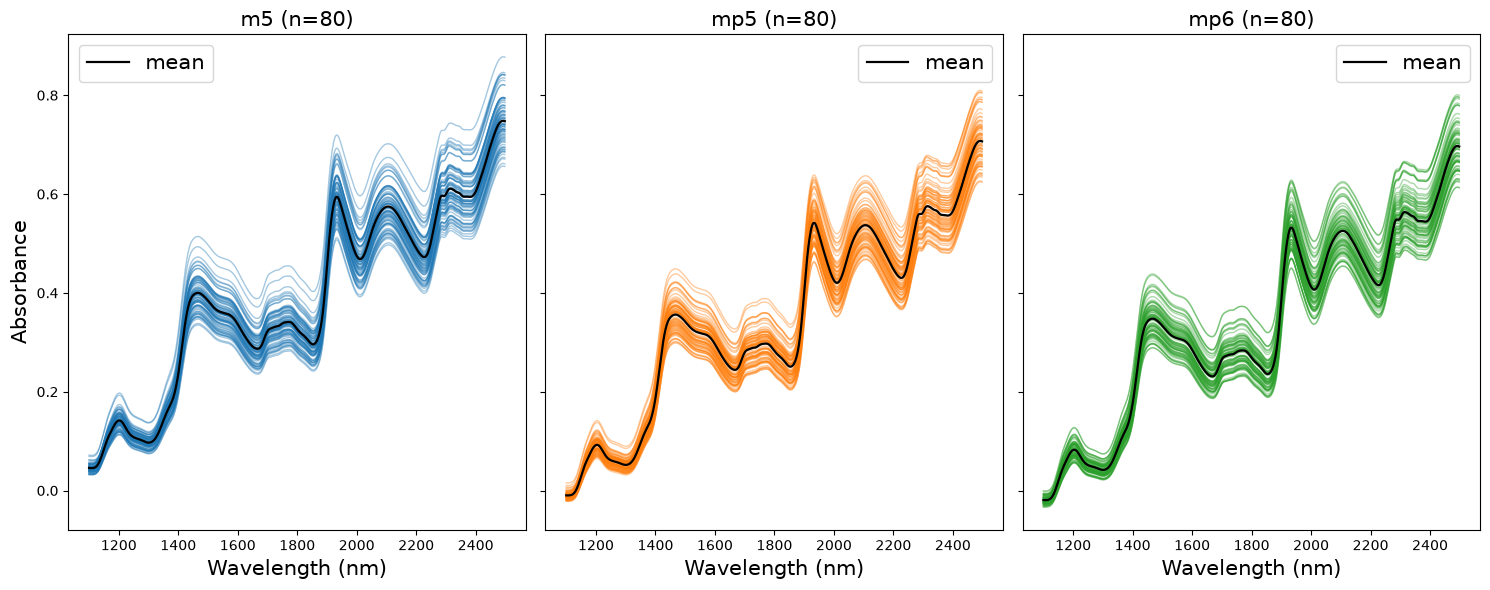

In [ ]:
fig = plot_spectra_overlay(dataset.wavelength_nm, dataset.spectra)
fig.savefig(FIGURES_DIR / "spectra_overlay_by_instrument.png", dpi=200)

**Observation** : les trois instruments partagent la même forme spectrale générale (bandes d'absorption de l'eau/protéines/amidon vers 1450, 1900-2000, 2100-2300 nm), avec un décalage de niveau (offset) visible entre m5 et mp5/mp6.


### 2. Décalage instrumental (m5 - mp5, m5 - mp6)

On prend m5 comme instrument de référence et on calcule la différence point par point avec mp5 et mp6, pour quantifier le décalage instrumental.

m5 - mp5: mean|diff|=0.0441, max|diff|=0.0936, std=0.0091
m5 - mp6: mean|diff|=0.0559, max|diff|=0.1015, std=0.0089


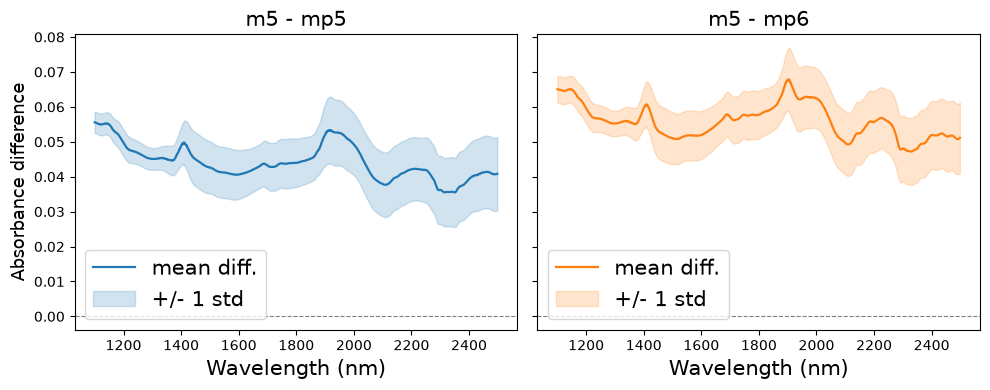

In [4]:
fig, diff_stats = plot_difference_curves(dataset.wavelength_nm, dataset.spectra, reference="m5")
for name, stats in diff_stats.items():
    print(f"m5 - {name}: mean|diff|={stats['mean_abs_diff']:.4f}, "
          f"max|diff|={stats['max_abs_diff']:.4f}, std={stats['std_diff']:.4f}")

**Observation** : le décalage moyen est de l'ordre de 0.04-0.06 unité d'absorbance, non nul sur toute la gamme spectrale, avec des pics locaux vers 1400 et 1900-2000 nm. mp6 montre un décalage moyen plus important que mp5 par rapport à m5. Ceci justifie la nécessité d'une étape de `calibration transfer` (notebook 03) si l'on veut appliquer un modèle appris sur m5 aux deux autres instruments.


### 3. Distribution des 4 cibles chimiques et corrélations

Les quatre propriétés à prédire sont Moisture (humidité), Oil (huile), Protein (protéine) et Starch (amidon), mesurées par méthode de référence pour les 80 échantillons.


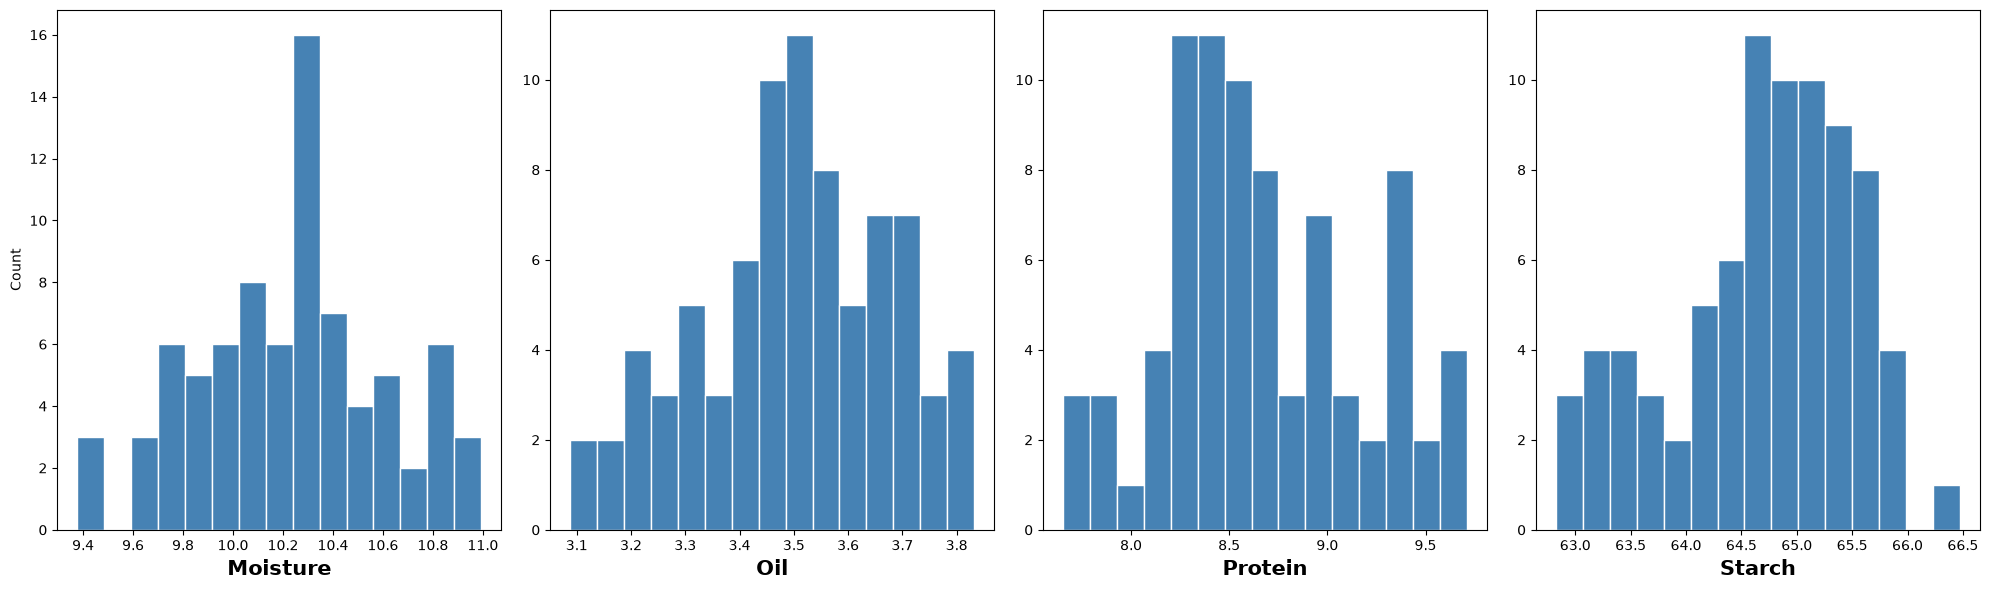

In [5]:
fig = plot_target_distributions(dataset.targets)

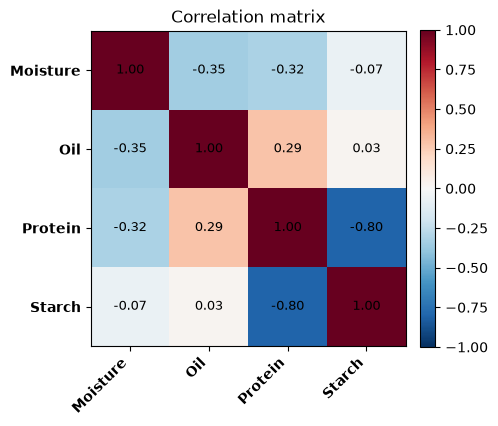

In [ ]:
fig, corr = plot_target_correlation_matrix(dataset.targets)
#corr.round(2)
fig.savefig(FIGURES_DIR / "target_correlation_matrix.png", dpi=200)

**Observation** : Protein et Starch sont fortement anti-corrélés (r = -0.80), ce qui est cohérent avec la composition biochimique du grain de maïs (une teneur en amidon plus élevée s'accompagne généralement d'une teneur en protéine plus faible). Moisture et Oil sont plus faiblement corrélées aux deux autres propriétés.

### 4. Standards NBS (verres de référence)

Des standards de verre NBS ont été mesurés sur chaque instrument. Ils ne contiennent pas de chimie du maïs mais servent de référence physique pour les expériences de `calibration transfer`.


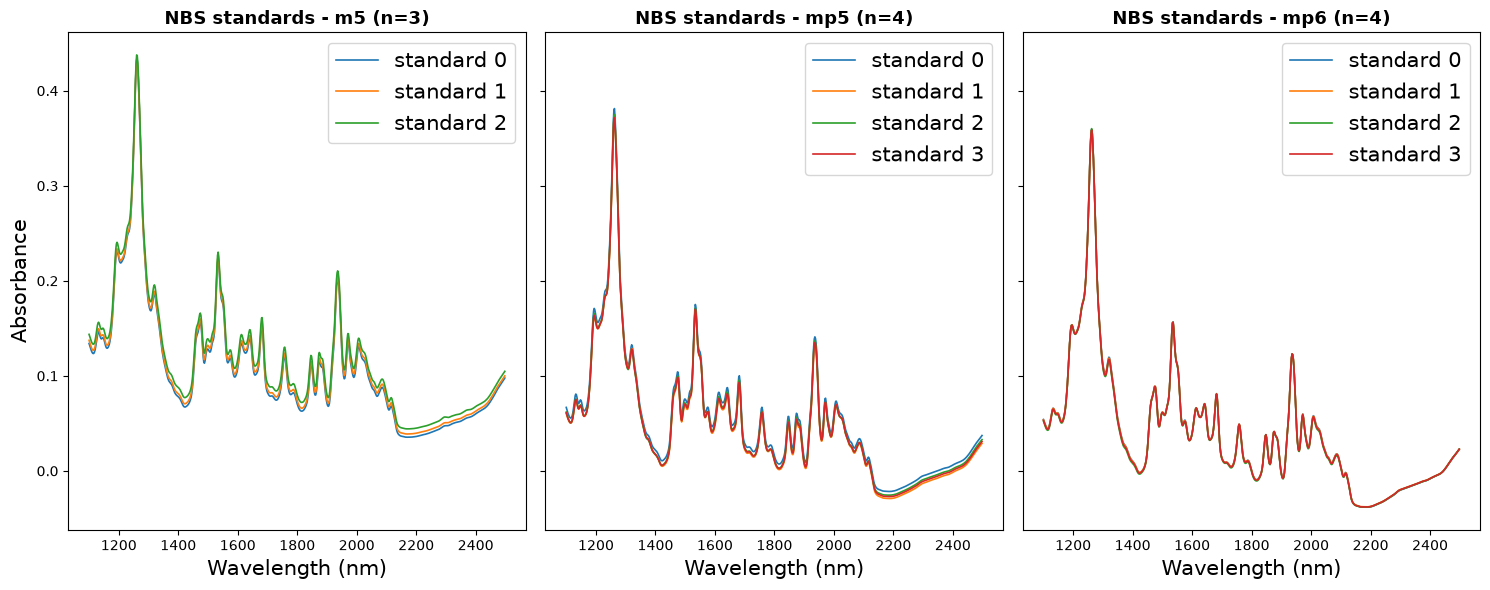

In [7]:
fig = plot_nbs_standards(dataset.wavelength_nm, dataset.nbs)

**Observation** : sur mp6, les standards NBS mesurés semblent quasiment identiques entre eux (les courbes se superposent visuellement). Point à vérifier avant de les utiliser comme base d'une standardisation (DS/PDS), car peu de variabilité entre standards limite l'information exploitable pour apprendre une transformation.

### 5. Structure spectrale : PCA par instrument (domain shift)

Une PCA est ajustée sur les spectres bruts des 3 instruments, puis les scores sont colorés par instrument pour visualiser le déplacement de domaine ("domain shift").

Explained variance ratio (PC1, PC2): 0.9598, 0.0373


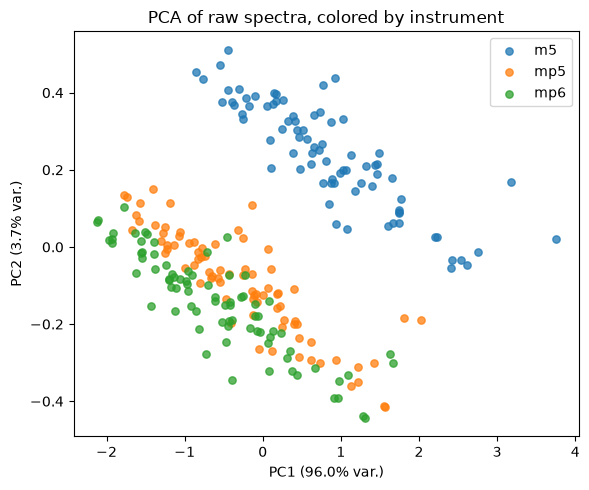

In [ ]:
fig, pca = plot_pca_by_instrument(dataset.spectra)
print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_[0]:.4f}, {pca.explained_variance_ratio_[1]:.4f}")
fig.savefig(FIGURES_DIR / "pca_by_instrument.png", dpi=200)

**Observation** : PC1 capture l'essentiel de la variance (96%) et sépare nettement m5 des deux autres instruments ; mp5 et mp6 se superposent davantage entre eux. Ceci confirme visuellement que le changement d'instrument déplace la structure spectrale, motivant le notebook 03 (robustesse inter-instruments et calibration transfer).


### 6. Diagnostic de la déformation spectrale (m5)
Un spectre NIR mesuré sur un échantillon réel (de la farine de maïs, pas une solution diluée idéale en laboratoire) ne suit pas exactement une relation simple entre absorbance et concentration : en plus du signal chimique (les pics d'absorption liés à la composition), le spectre est affecté par des phénomènes physiques sans lien avec la chimie, comme la diffusion de la lumière (sensible à la granulométrie et au tassement de l'échantillon), le bruit de mesure, ou une dérive de la ligne de base. Ces déformations se traduisent généralement par un terme multiplicatif (qui modifie l'intensité globale du signal, comme un allongement effectif du trajet optique) et des termes additifs (décalage de ligne de base, bruit) qui se superposent au signal chimique utile. 


**Étape 1 - Identification visuelle à partir du spectre brut.** 


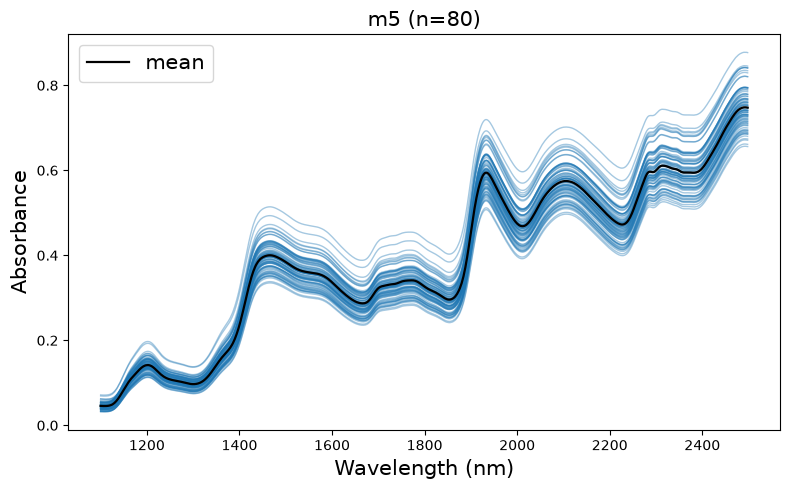

In [9]:
fig = plot_spectra_overlay(dataset.wavelength_nm, {'m5' : dataset.spectra['m5']}, figsize=[8, 5])

Le spectre moyen de m5 (ci-dessus) montre une tendance croissante avec la longueur d'onde, signe d'un effet additif. On le remarque au fait que la dispersion entre les spectres ne dépend pas du niveau du spectre. *"Ce phénomène n'est pas dû à la chimie, mais à la diffusion de la lumière. La chimie, elle, est responsable des pics d'absorption visibles sur cette courbe croissante."* Cette observation peut parfois prêter à confusion entre un effet additif et une ligne de base croissante combinée à un effet multiplicatif, d'où l'étape 2.

**Etape 2 - quantifier.**

Un moyen assez simple de différencier les deux types d'effets utilise un graphique particulier, qui consiste à remplacer l'axe des abscisses, initialement l'échelle des longueurs d'onde, par les valeurs du spectre moyen. Il s'agit donc de tracer toutes valeurs d'intensité observées, en fonction de toutes les intensités du spectre moyen. Une forme en millefeuille est caractéristique d'un effet additif. Une forme en cône est caractéristique d'un effet multiplicatif.

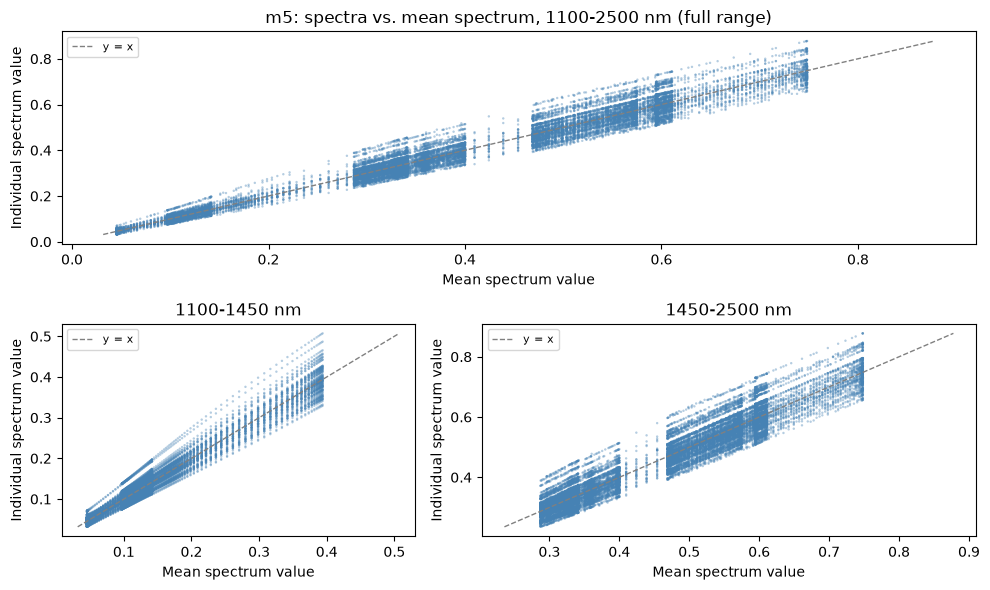

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from corn_nir.visualization import plot_spectra_vs_mean_spectrum

wl = dataset.wavelength_nm
X_m5 = dataset.spectra["m5"]

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 7, height_ratios=[1, 1])

ax_full = fig.add_subplot(gs[0, :])     # rangée du haut, pleine largeur
ax_cone = fig.add_subplot(gs[1, :3])     # bas-gauche, 1 colonne sur 4 -> 350 nm
ax_mille = fig.add_subplot(gs[1, 3:])   # bas-droite, 3 colonnes sur 4 -> 1050 nm (même ratio que les plages)

plot_spectra_vs_mean_spectrum(
    X_m5, ax=ax_full, title="m5: spectra vs. mean spectrum, 1100-2500 nm (full range)",
)

mask_cone = (wl >= 1100) & (wl < 1450)
plot_spectra_vs_mean_spectrum(
    X_m5[:, mask_cone], ax=ax_cone, title="1100-1450 nm",
)

mask_millefeuille = (wl >= 1450) & (wl <= 2500)
plot_spectra_vs_mean_spectrum(
    X_m5[:, mask_millefeuille], ax=ax_mille, title="1450-2500 nm",
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "spectra_vs_mean_m5.png", dpi=200)

Le graphique du haut, sur l'ensemble de la plage (1100-2500 nm), ne permet pas de trancher franchement entre millefeuille et cône.

En séparant par plage de longueurs d'onde, la réponse devient nette. Sur 1100-1450 nm (bas-gauche), les points s'écartent visiblement de la diagonale y=x à mesure que la valeur moyenne augmente : le nuage s'évase en partant d'un point resserré près de l'origine (un cône), signature d'un effet multiplicatif. Sur 1450-2500 nm (bas-droite), les points restent regroupés en bandes dont la largeur reste à peu près constante tout le long de la diagonale (un millefeuille), signature d'un effet additif.

Conclusion : l'effet multiplicatif n'est pas une propriété globale du spectre m5, il est concentré sur la région 1100-1450 nm ; le reste du spectre (1450-2500 nm) est dominé par un effet additif.

Le prétraitement SNV est l'une des méthodes utilisées pour traiter à la fois un effet multiplicatif et un effet additif.

### 7. Le niveau du spectre porte-t-il du signal ?

On colore chaque spectre de m5 par la valeur de la cible à prédire, pour voir si le niveau global
du spectre covarie avec la chimie.

#### Spectres bruts

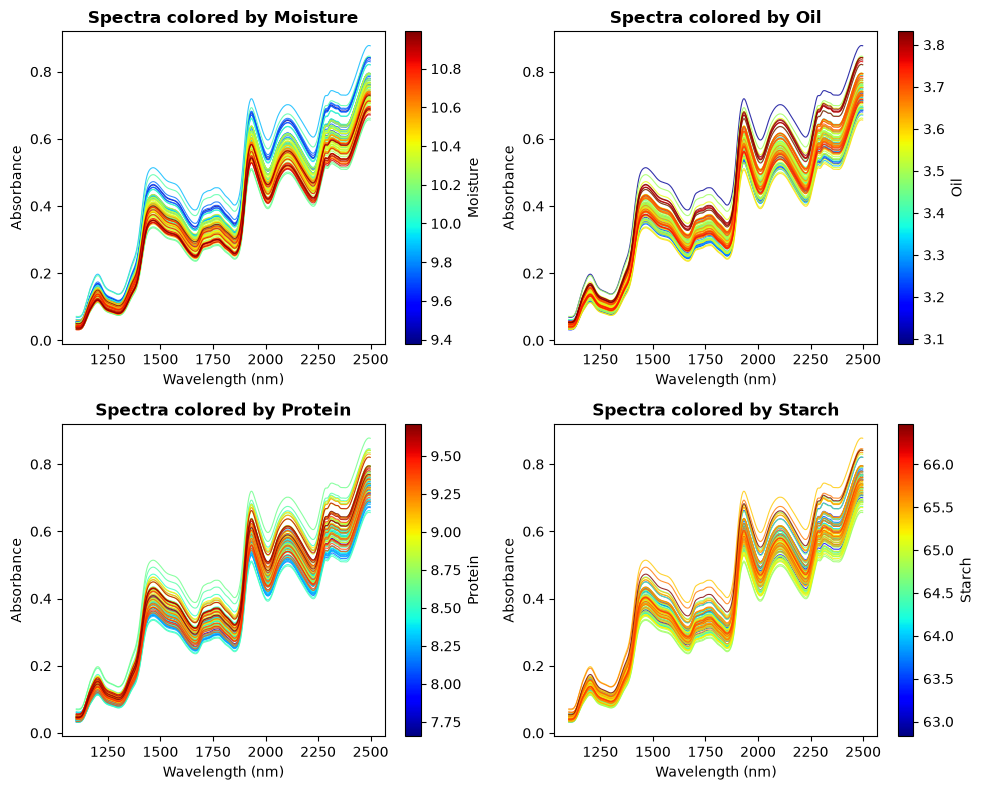

In [ ]:
from corn_nir.visualization import plot_spectra_colored_by_all_targets

fig = plot_spectra_colored_by_all_targets(dataset.wavelength_nm, dataset.spectra["m5"], dataset.targets)
fig.savefig(FIGURES_DIR / "spectra_colored_by_target_m5.png", dpi=200)

#### Spectres prétraités avec SNV

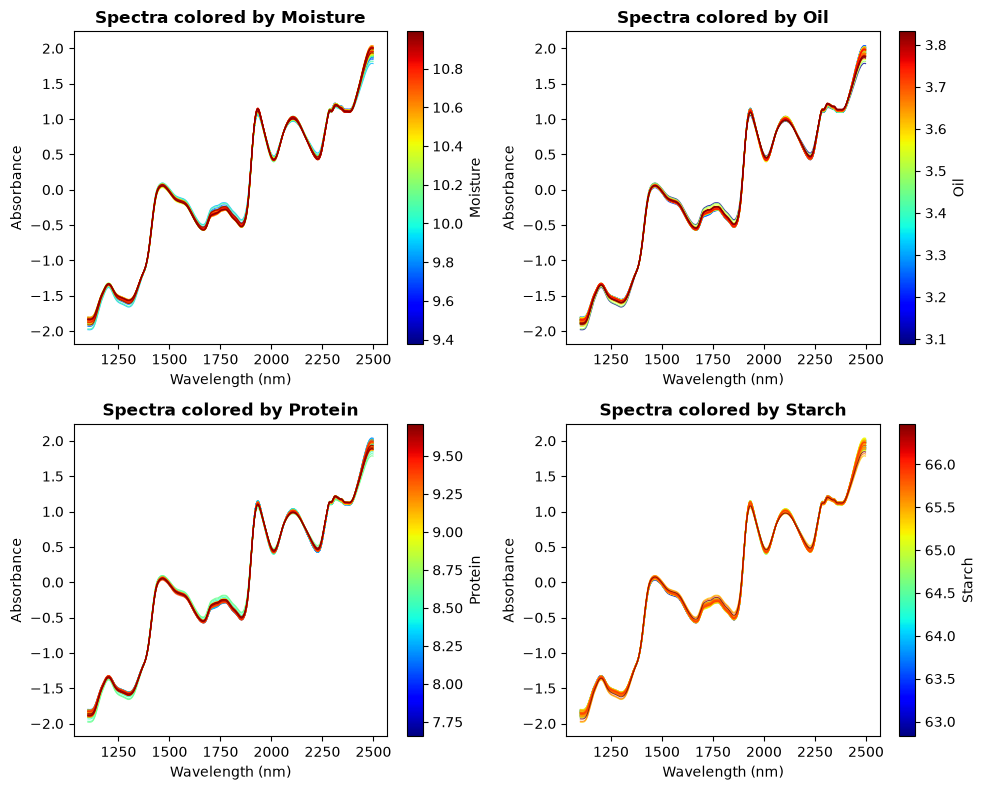

In [12]:
from corn_nir.preprocessing import build_preprocessing
# Après SNV
snv = build_preprocessing("snv")
X_snv = snv.fit_transform(dataset.spectra["m5"])

fig_snv = plot_spectra_colored_by_all_targets(dataset.wavelength_nm, X_snv, dataset.targets)

On compare les mêmes spectres, colorés par cible, avant et après SNV.

En brut, un dégradé de couleur est net pour Moisture et Oil. Les spectres se séparent visiblement par niveau selon la valeur de la cible. Pour Protein et Starch, les couleurs restent mélangées, sans stratification claire.

Après SNV, le dégradé disparaît sur les 4 figures : les spectres se superposent presque parfaitement, et la couleur ne suit plus aucun ordre visible.

### 8. Un correcteur plus spécifique pour l'effet additif : `Detrend`, sur la plage 1450-2500 nm

La partie 7 montre que SNV efface le dégradé couleur-par-cible sur les 4 figures à la fois : SNV corrige l'effet additif et l'effet multiplicatif simultanément (centrage-réduction ligne par ligne), sans distinction entre les deux. Or le diagnostic de la partie 6 a montré que ces deux effets ne sont pas mélangés partout de la même façon : l'effet est majoritairement multiplicatif entre 1100 et 1450 nm ("cone"), et majoritairement additif au-delà de 1450 nm ("millefeuille"). Cette dernière plage couvre la majeure partie des 700 longueurs d'onde.

Sur cette plage additive dominante, un correcteur plus spécifique que SNV suffit : `Detrend` (Barnes, Dhanoa & Lister, 1989) soustrait, par échantillon, la droite de régression du spectre contre la longueur d'onde. Contrairement à SNV/MSC, qui corrigent aussi l'échelle, ce qui n'est pas nécessaire ici puisque l'effet multiplicatif est concentré ailleurs.


In [ ]:
from corn_nir.preprocessing import Detrend

crop_mask = dataset.wavelength_nm >= 1450
wavelength_cropped = dataset.wavelength_nm[crop_mask]
X_cropped = dataset.spectra["m5"][:, crop_mask]

detrend = Detrend(wavelength_nm=wavelength_cropped, degree=1)
X_detrend = detrend.fit_transform(X_cropped)
print(f"Plage retenue : {wavelength_cropped.min():.0f}-{wavelength_cropped.max():.0f} nm "
      f"({X_detrend.shape[1]} longueurs d'onde, contre {dataset.spectra['m5'].shape[1]} sur la plage complète)")

Plage retenue : 1450-2498 nm (525 longueurs d'onde, contre 700 sur la plage complète)


On compare d'abord la forme des spectres bruts et après `Detrend` :


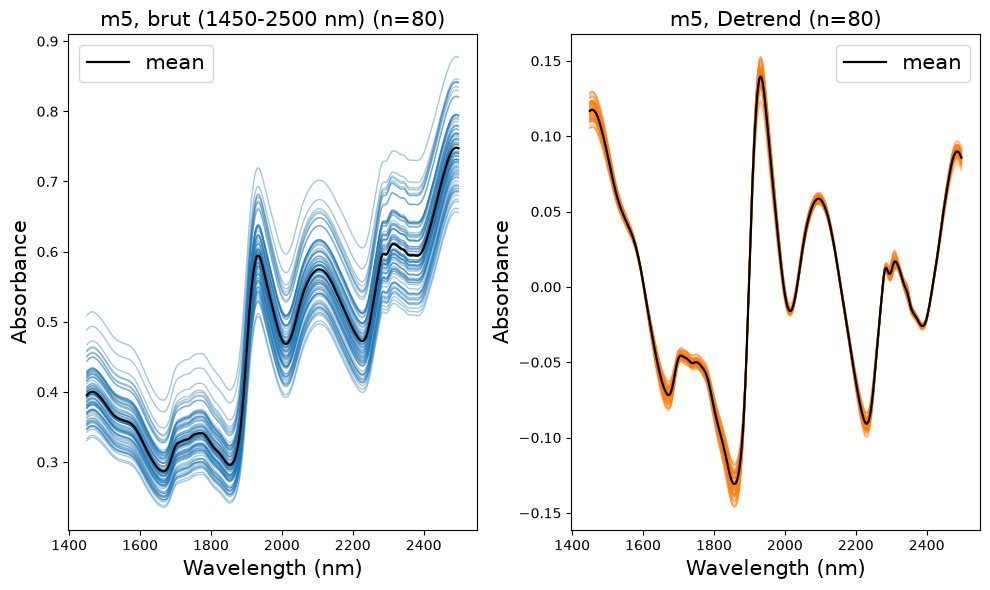

In [ ]:
fig = plot_spectra_overlay(
    wavelength_cropped,
    {"m5, brut (1450-2500 nm)": X_cropped, "m5, Detrend": X_detrend},
    sharey=False,
)
fig.savefig(FIGURES_DIR / "spectra_raw_vs_detrend_m5.png", dpi=200)

Après `Detrend`, les spectres se superposent en une bande étroite avec des extrema nets et reconnaissables : une chute marquée vers 1850-1870 nm suivie d'un pic net vers 1920-1950 nm (la bande O-H de l'eau), puis des pics plus petits vers 2100 et 2300-2320 nm. Une forme visuellement plus lisible que le faisceau brut, où une tendance de fond décalait chaque spectre verticalement sans faire ressortir ces structures. 

On reprend maintenant la comparaison couleur-par-cible de la partie 7 (brut vs SNV), en ajoutant `Detrend` :

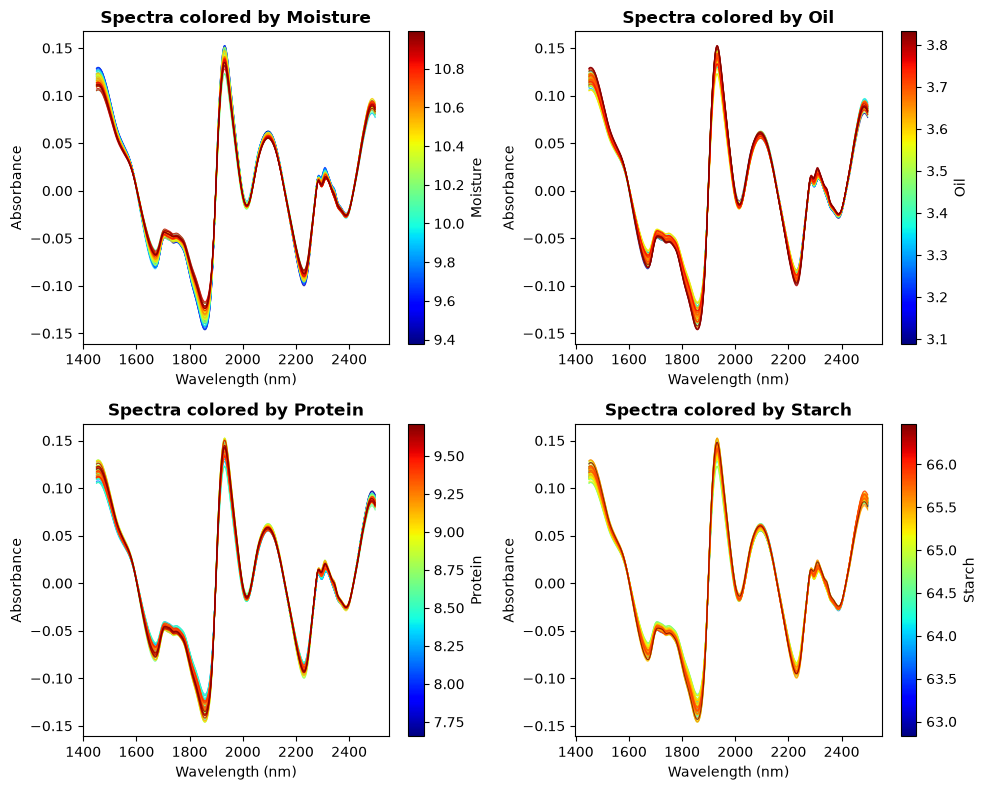

In [15]:
fig_detrend = plot_spectra_colored_by_all_targets(wavelength_cropped, X_detrend, dataset.targets)

Comme après SNV, la superposition des spectres est nettement plus étroite qu'en brut sur les 4 figures. On distingue toutefois un peu plus de structure colorée qu'après SNV.

**Prétraitement initial retenu : `Detrend`, sur 1450-2500 nm.** Il cible précisément la déformation additive dominante sur cette plage.

Deux réserves, prévues comme travail à suivre et non encore réalisées : (1) la coupure à 1450 nm retire la bande O-H de l'eau vers 1450-1500 nm, ce qui devrait coûter cher à Moisture spécifiquement (contrairement à Oil/Protein/Starch, dont les bandes selon la littérature se situent surtout au-delà de 1500 nm). Une coupure à 1500 nm n'a pas encore été testée ici ; ce serait une piste à explorer pour ce sous-groupe de cibles. (2) La comparaison empirique complète de la Phase D (`02_prediction_intra_instrument.ipynb`) continue de tester la plage complète (1100-2500 nm) avec les 7 prétraitements existants (brut compris), sans inclure Detrend. Le choix fait ici n'est qu'un point de départ motivé, pas une décision finale.

### 9. ACP : scores et loadings (`Detrend`, 1450-2500 nm)

Avant de construire un modèle, on regarde la structure des données avec une ACP sur le prétraitement retenu (scores colorés par cible, loadings).


In [ ]:
from corn_nir.pca import compute_pca

pca_result = compute_pca(X_detrend, variance_threshold=0.95)
print(f"Composantes retenues (95% variance) : {pca_result['n_components']}")

Composantes retenues (95% variance) : 3


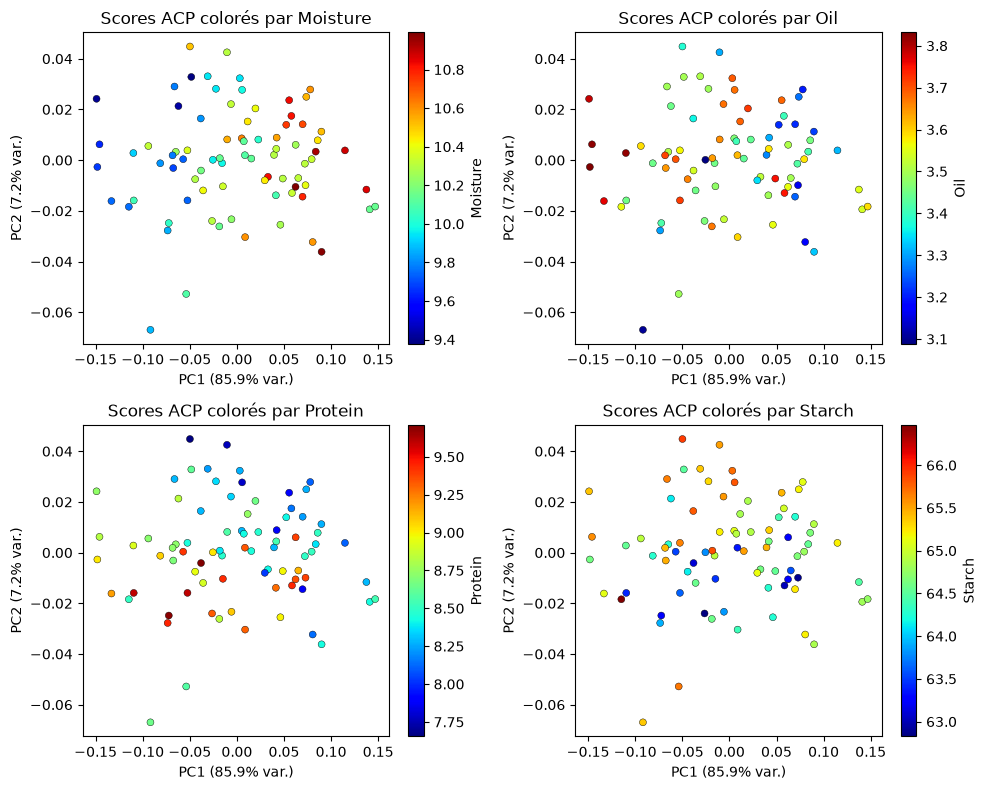

In [17]:
from corn_nir.visualization import plot_pca_scores_by_target

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, dataset.targets.columns):
    plot_pca_scores_by_target(pca_result["scores"], dataset.targets[col].values, explained_var=pca_result["explained_variance_ratio"], target_name=col, ax=ax)
fig.tight_layout()

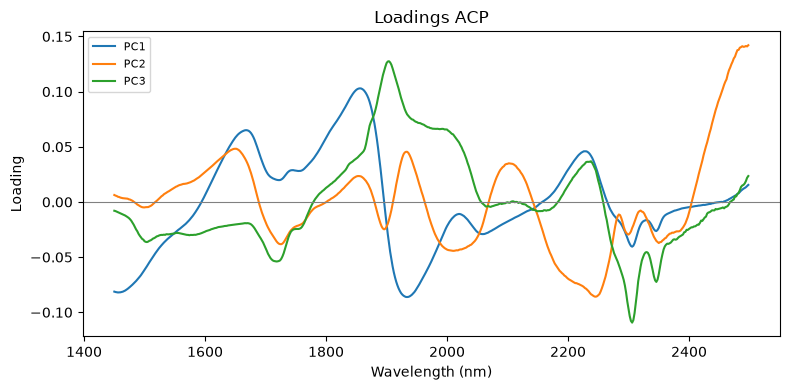

In [18]:
from corn_nir.visualization import plot_pca_loadings
fig = plot_pca_loadings(wavelength_cropped, pca_result["components"])

In [19]:
# corrélations entre les PC et les targets
import pandas as pd

corr_scores_targets = pd.DataFrame({
    target: [
        np.corrcoef(pca_result["scores"][:, i], dataset.targets[target].values)[0, 1]
        for i in range(pca_result["scores"].shape[1])
    ]
    for target in dataset.targets.columns
}, index=[f"PC{i+1}" for i in range(pca_result["scores"].shape[1])])
corr_scores_targets.round(3)

,Moisture,Oil,Protein,Starch
PC1,0.713,-0.361,-0.320,-0.107
PC2,-0.048,0.081,-0.474,0.322
PC3,0.546,-0.531,-0.346,0.174


3 composantes suffisent à atteindre 95% de variance (86%, 7%, 3%). Les loadings montrent que PC1 concentre l'essentiel de son poids autour de 1850-1860 nm et PC3 autour de 1900-1908 nm : deux zones proches du pic principal du spectre moyen (partie 1, bande O-H de l'eau). PC2 concentre le sien en bord de plage (2490-2500 nm).

Les scores de l'ACP corrèlent avec plusieurs cibles : PC1 avec Moisture (r=0.71) et Oil (r=-0.36), PC3 avec Moisture (r=0.55) et Oil (r=-0.53), PC2 avec Protein (r=-0.47). Starch ne corrèle avec aucun des 3. L'ACP reste non supervisée : elle maximise la variance totale du nuage de points, pas la corrélation avec une cible en particulier, à la différence d'une PLS.


## Suite

`02_prediction_intra_instrument.ipynb` : construction et validation des modèles (baseline PLSR, comparaison de prétraitements, VIP/ElasticNet, comparaison à des modèles ML).
